# Projeto Multidisciplinar I

## Apresentação e discussão

Projeto proposto pelo professor da formação:

O projeto Multidisciplinar I consiste na simulação de dados envolvendo pesos e alturas de indivíduos, calculando o IMC (índice de Massa Corporal) e relacionando com dados simulados sobre existência de problemas cardíacos. A simulação deverá contar com dados pseudoaleatórios gerados por simulação computacional e deverá haver correspondência entre problemas cardiácos com a medida do IMC. Ou seja, iremos supor que exista uma correspondência óbvia entre as medidas (modelada matematicamente por equação e coeficientes arbitrariamente definidos). Para cada sexo (sendo eles definidos de forma aleatória).

Você, portanto, simulará via randomização (aleatoriedade) as alturas dentro de uma faixa bem definida. Em seguida, aplicará uma equação que determine, com algum grau de aleatoriedade, os pesos dos indivíduos. Logo depois, calculará o IMC e definirá para cada indivíduo a existência (sim ou não) de problemas cardíacos, ambos com algum grau mínimo de correspondência com o IMC.

Ao final, faça as análises necessárias com medidas de dispersão e tendência central. Crie as funções para tal. E interprete os IMCs obtido conforme WHO (Organização Mundial da Saúde).

Os dados devem estar reunidos em uma tabela.

Para gerar dados aleatórios utilize o pacote numpy através do subpacote random e a função normal (da distribuição normal).

## Importando pacotes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42) # Para reproduzir o mesmo resultado aleatório

## Estruturando amostra -> Altura + Peso + Sexo

Decisões que eu tomei:

1 - Tamanho da minha amostra: 200.000 pessoas;

2 - Valores das alturas: média 1.70; desvio padrão de 0.15 (15 centímetros);

3 - Aleatoriedade dos pesos: 
    
    -> intercepto:  média 20 kg; desvio padrão 5kg;
    -> coeficiente angular: média 30 kg; desvio padrão 5kg (para cada 1 cm de altura, a média varia de 0,3 kg com desvio padrão de 0,05 kg)
    -> erro: média 0 kg; desvio padrão 2 kg
    
    
4 - Peso determinístico: peso = intercepto + (coeficiente angular * altura) + ruído

5 - Aleatoriedade dos sexos: média 1; desvio padrão 1 (se o valor for menor ou igual à 1 = Sexo F, senão Sexo M)

In [2]:
# Definindo o tamanho da minha amostra e simulando dados referentes à alturas
tamanho_amostra = 200000
alturas = np.random.normal(1.70, 0.15, tamanho_amostra)

print(alturas)
print(len(alturas))

[1.77450712 1.67926035 1.79715328 ... 1.72400299 1.82835096 1.5402578 ]
200000


In [3]:
# Fórmula -> peso = intercepto + (coeficiente angular * altura) + ruído

# Grau de aleatoriedade para definir o peso conforme a altura
intercepto = np.random.normal(20, 5, tamanho_amostra)
coeficiente_angular = np.random.normal(30, 5, tamanho_amostra)
ruido = np.random.normal(0,2, tamanho_amostra)

# Peso determinístico
pesos = intercepto + (coeficiente_angular * alturas) + ruido

print(pesos)
print(len(pesos))


[111.62881237  68.44280398  50.2510634  ...  76.54583619  76.51419775
  67.34277004]
200000


In [4]:
# Simulando dados referentes ao sexo das pessoas
sexo_1 = np.random.normal(1,1,tamanho_amostra)
sexo_2 = np.where(sexo_1 <= 1, 'F', 'M')

print(sexo_2)
print(len(sexo_2))
    

['M' 'M' 'M' ... 'F' 'M' 'M']
200000


## Calculando IMC

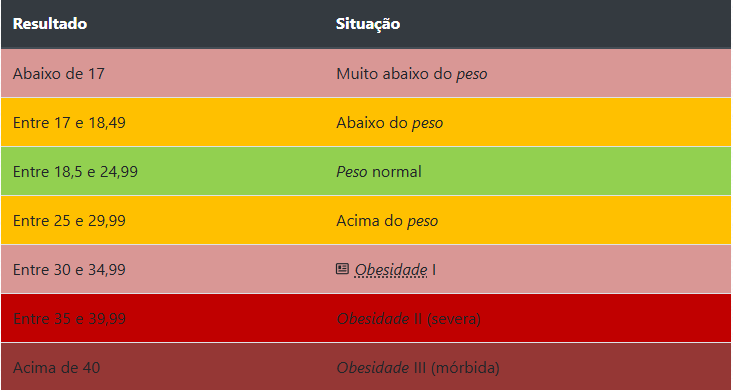

In [5]:
# Classificação OMS -> Organização Mundial de Saúde
# Correspondência com problemas cardíacos
# Optei por criar a categoria 'Indefinido' para os IMCs que caem nas lacunas entre os limites das faixas

imc = (pesos/alturas ** 2)

print(imc)
print(len(imc))

riscos_imc = np.where(imc < 17, 'Muito abaixo do peso',
             np.where((imc >= 17) & (imc <= 18.49), 'Abaixo do peso',
             np.where((imc >= 18.5) & (imc <= 24.99), 'Peso normal',
             np.where((imc >= 25) & (imc <= 29.99), 'Acima do peso',
             np.where((imc >= 30) & (imc <= 34.99), 'Obesidade I',
             np.where((imc >= 35) & (imc <= 39.99), 'Obesidade II',
             np.where(imc >= 40, 'Obesidade III (mórbida)', 'Indefinido')))))))
                             

print(riscos_imc)
print(len(riscos_imc))

problema_cardiaco = np.where((riscos_imc == 'Acima do peso') |
                             (riscos_imc == 'Obesidade I') |
                             (riscos_imc == 'Obesidade II'),
                             'Parcial',
                             np.where(riscos_imc == 'Obesidade III (mórbida)', 'Sim',
                                      np.where(riscos_imc == 'Indefinido', 'Indefinido', 'Não')))

print(problema_cardiaco)
print(len(problema_cardiaco))



[35.4503731  24.27122653 15.55876125 ... 25.75405032 22.88879341
 28.38599619]
200000
['Obesidade II' 'Peso normal' 'Muito abaixo do peso' ... 'Acima do peso'
 'Peso normal' 'Acima do peso']
200000
['Parcial' 'Não' 'Não' ... 'Parcial' 'Não' 'Parcial']
200000


## Unindo as informações de cada indivíduo

In [6]:
uniao = zip(alturas, pesos, sexo_2,imc, riscos_imc, problema_cardiaco)
uniao_array = np.array(list(uniao))
print(uniao_array)

[['1.774507122951685' '111.62881236603454' 'M' '35.450373100991584'
  'Obesidade II' 'Parcial']
 ['1.6792603548243223' '68.44280398347715' 'M' '24.271226525842486'
  'Peso normal' 'Não']
 ['1.7971532807151038' '50.251063399491024' 'M' '15.558761248994793'
  'Muito abaixo do peso' 'Não']
 ...
 ['1.7240029945606707' '76.54583619383521' 'F' '25.754050324314562'
  'Acima do peso' 'Parcial']
 ['1.8283509630271622' '76.5141977456438' 'M' '22.888793410184846'
  'Peso normal' 'Não']
 ['1.5402578048173894' '67.34277003855212' 'M' '28.385996191813692'
  'Acima do peso' 'Parcial']]


In [7]:
dados = ['altura', 'peso', 'sexo', 'imc','riscos_imc', 'problema_cardiaco']
df = pd.DataFrame(uniao_array, columns=dados)

df.head(10)

,altura,peso,sexo,imc,riscos_imc,problema_cardiaco
0,1.774507122951685,111.62881236603454,M,35.450373100991584,Obesidade II,Parcial
1,1.6792603548243223,68.44280398347715,M,24.271226525842486,Peso normal,Não
2,1.7971532807151038,50.251063399491024,M,15.558761248994793,Muito abaixo do peso,Não
3,1.9284544784612037,75.15524810502049,F,20.208800165970892,Peso normal,Não
4,1.6648769937914996,70.58187169549538,M,25.464131407171486,Acima do peso,Parcial
5,1.6648794564576228,64.92210585231926,M,23.42216356989977,Peso normal,Não
6,1.9368819223261087,83.88677157543826,F,22.36079238020753,Peso normal,Não
7,1.8151152093729364,79.78730697677729,M,24.21728289503041,Peso normal,Não
8,1.6295788421097572,59.72268690718398,F,22.48995485625063,Peso normal,Não
9,1.7813840065378947,81.18737933574837,F,25.58429330190476,Acima do peso,Parcial


In [8]:
df.dtypes

altura               object
peso                 object
sexo                 object
imc                  object
riscos_imc           object
problema_cardiaco    object
dtype: object

In [9]:
df['altura'] = df['altura'].astype('float64')
df['peso'] = df['peso'].astype('float64')
df['imc'] = df['imc'].astype('float64')
df.dtypes

altura               float64
peso                 float64
sexo                  object
imc                  float64
riscos_imc            object
problema_cardiaco     object
dtype: object

## Estatística descritiva

In [10]:
def tabela_frequencia(var):

	frequencia_relativa = var.value_counts()/len(var)

	return pd.DataFrame({
       "Freq. Absoluta": var.value_counts(),
       "Freq. Relativa": frequencia_relativa,
       "Freq. Relativa %": (frequencia_relativa) * 100
    })

def medidas_tendencia_central(var):
	return{
		"Média": var.mean(),
		"Mediana": var.median(), # Valor central após ordenar os dados
	}

def medidas_dispersao(var):
	return{
		"Amplitude": var.max() - var.min(),
		"Variância": var.var(), # Mede a dispersão em relação à média
		"Desvio padrão": var.std(), # Raiz quadrada da variância
		"Coeficiente de variação": (var.std()/var.mean()) * 100 # Mede a dispersão em relação à média em formato de porcentagem
    }

def medidas_posicao(var):
    q1 = var.quantile(0.25)
    q2 = var.quantile(0.50)
    q3 = var.quantile(0.75)

    iqr = q3 - q1
    limite_superior = q3 + (1.5 * iqr)
    limite_inferior = q1 - (1.5 * iqr)
    valores_outliers = list(var[(var > limite_superior) | (var < limite_inferior)])

    return {
        "Q1": q1,
        "Q2": q2,
        "Q3": q3,
        "Intervalo Interquartil (IQR)": iqr,
        "Limite superior": limite_superior,
        "Limite inferior": limite_inferior,
        "QTD. Valores Outliers": len(valores_outliers)
    }


In [11]:
tabela_frequencia(df['riscos_imc'])

,Freq. Absoluta,Freq. Relativa,Freq. Relativa %
riscos_imc,,,
Peso normal,94194,0.470970,47.0970
Acima do peso,65942,0.329710,32.9710
Obesidade I,21287,0.106435,10.6435
Abaixo do peso,7837,0.039185,3.9185
Muito abaixo do peso,5785,0.028925,2.8925
Obesidade II,3938,0.019690,1.9690
Obesidade III (mórbida),657,0.003285,0.3285
Indefinido,360,0.001800,0.1800


In [12]:
tabela_frequencia(df['problema_cardiaco'])

,Freq. Absoluta,Freq. Relativa,Freq. Relativa %
problema_cardiaco,,,
Não,107816,0.539080,53.9080
Parcial,91167,0.455835,45.5835
Sim,657,0.003285,0.3285
Indefinido,360,0.001800,0.1800


In [13]:
tabela_frequencia(df['sexo'])

,Freq. Absoluta,Freq. Relativa,Freq. Relativa %
sexo,,,
F,100509,0.502545,50.2545
M,99491,0.497455,49.7455


In [14]:
# Características Altura
print(medidas_tendencia_central(df['altura']))
print(medidas_dispersao(df['altura']))

{'Média': 1.7001460926632752, 'Mediana': 1.7002554632037012}
{'Amplitude': 1.3541577880715652, 'Variância': 0.02249642822982367, 'Desvio padrão': 0.14998809362687315, 'Coeficiente de variação': 8.822070895796791}


In [15]:
# Características Peso
print(medidas_tendencia_central(df['peso']))
print(medidas_dispersao(df['peso']))


{'Média': 70.96969211875792, 'Mediana': 70.72521202539045}
{'Amplitude': 108.32384421282462, 'Variância': 122.14431629227931, 'Desvio padrão': 11.05189197795017, 'Coeficiente de variação': 15.572692579046791}


In [16]:
# Características IMC
print(medidas_tendencia_central(df['imc']))
print(medidas_dispersao(df['imc']))

{'Média': 24.861001273206835, 'Mediana': 24.54806422057559}
{'Amplitude': 49.37277573849258, 'Variância': 21.081406625245382, 'Desvio padrão': 4.591449294639481, 'Coeficiente de variação': 18.468480992307303}


## Respostas das perguntas

### 1. O IMC afeta a chance de ter problemas cardíacos?

Levando em consideração aos dados simulados e com o objetivo de identificar riscos cardíacos em IMCs elevados, sim, O IMC afeta a chance do desenvolvimento de problemas cardíacos. Embora essa minha análise pareça ser uma referência circular, por eu ter feitos tais classificações (SIM, Parcial, Não) para desenvolvimentos cardíacos por meio do número do IMC, foi uma decisão com base na própria classificação da OMS. A própria OMS evidencia que quanto maior o IMC, maior a chance do desenvolvimento de doenças cardiovasculares.

Nas análises que eu realizei abaixo, separando minha amostra em dois grupos, pessoas com possíveis desenvolvimento de problemas cardíacos (categoria SIM/Parcial) e sem (categoria NÃO), fica evidente que o primeiro grupo apresenta um IMC elevado, enquanto o segundo grupo apresenta um IMC que se concentra no valor 'Normal'.

Observação: certamente pessoas muito abaixo do peso podem desenvolver complicações em sua saúde, mas o objetivo desta análise é identificar problemas consecutivos de IMCs elevados.

#### Pessoas com maiores chances de desenvolver problemas cardíacos por conta do excesso de peso

{'Média': 28.793304007126153, 'Mediana': 27.999956385320537}
{'Amplitude': 33.07573978018556, 'Variância': 10.111788747600261, 'Desvio padrão': 3.1799038896797276, 'Coeficiente de variação': 11.043900654446334}
Quantidade de indivíduos com maior chance de desenvolver problemas cardíacos: 91824
Menor IMC registrado: 25.000017126903987
Maior IMC registrado: 58.07575690708954
{'Q1': 26.36914773415849, 'Q2': 27.999956385320537, 'Q3': 30.396067700058097, 'Intervalo Interquartil (IQR)': 4.026919965899609, 'Limite superior': 36.43644764890751, 'Limite inferior': 20.328767785309076, 'QTD. Valores Outliers': 2654}


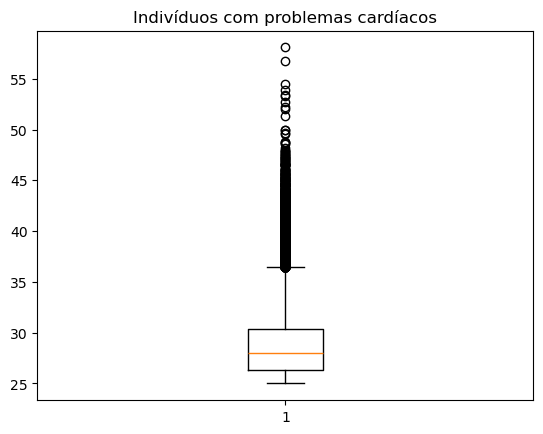

,Freq. Absoluta,Freq. Relativa,Freq. Relativa %
riscos_imc,,,
Acima do peso,65942,0.718135,71.813469
Obesidade I,21287,0.231824,23.182392
Obesidade II,3938,0.042886,4.288639
Obesidade III (mórbida),657,0.007155,0.715499


In [17]:
com_problemas = df[(df['problema_cardiaco'] == 'Sim') | (df['problema_cardiaco'] == 'Parcial')]

print(medidas_tendencia_central(com_problemas['imc']))
print(medidas_dispersao(com_problemas['imc']))

print(f'Quantidade de indivíduos com maior chance de desenvolver problemas cardíacos: {com_problemas['imc'].count()}')
print(f'Menor IMC registrado: {com_problemas['imc'].min()}')
print(f'Maior IMC registrado: {com_problemas['imc'].max()}')

print(medidas_posicao(com_problemas['imc']))
plt.boxplot(com_problemas['imc'])
plt.title('Indivíduos com problemas cardíacos')
plt.show()

# Média: 28.793304007126153
# Mediana: 27.999956385320537
# Coeficiente de variação: 11.043900654446334% (baixa variabilidade em relação à média)

# 25% dos valores do IMC estão abaixo de 26.36914773415849, com alta concentração dos valores
# 25% dos valores do IMC estão acima de 30.396067700058097, com baixa concentração dos valores
# Há muitos valores outliers, que ultrapassam de 36.43644764890751

# Conclusão: As pessoas da amostra que possuem chances de desenvolver problemas cardíacos por conta do excesso de peso, estão concentradas em faixas do IMC que vão do menor valor (25.000017126903987)
# até o valor da mediana 27.999956385320537, a qual divide os dados em 50%. Os outros 50% dos dados, acima do valor da mediana, possuem uma alta dispersão dos valores (baixa concentração). Indicando que as pessoas
# se concentram na classificação 'Acima do peso'.

tabela_frequencia(com_problemas['riscos_imc'])

#### Pessoas com menores chances de desenvolver problemas cardíacos por conta do excesso de peso

{'Média': 21.507932658363313, 'Mediana': 21.91554163921069}
{'Amplitude': 16.286902249469975, 'Variância': 6.017273637280453, 'Desvio padrão': 2.4530131751135076, 'Coeficiente de variação': 11.405155549246425}
Quantidade de indivíduos com menor chance de desenvolver problemas cardíacos: 107816
Menor IMC registrado: 8.702981168596962
Maior IMC registrado: 24.98988341806694
{'Q1': 19.95516352193473, 'Q2': 21.91554163921069, 'Q3': 23.49089100058029, 'Intervalo Interquartil (IQR)': 3.535727478645562, 'Limite superior': 28.794482218548634, 'Limite inferior': 14.651572303966386, 'QTD. Valores Outliers': 1009}


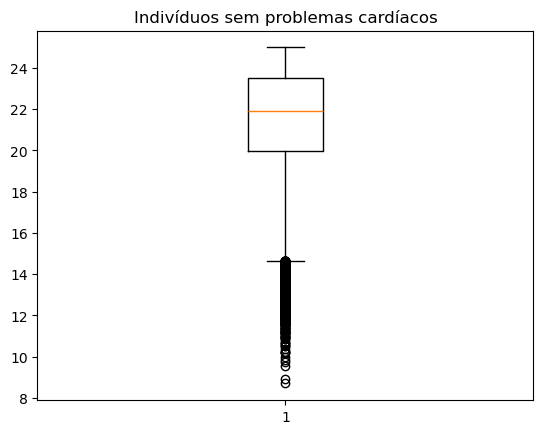

,Freq. Absoluta,Freq. Relativa,Freq. Relativa %
riscos_imc,,,
Peso normal,94194,0.873655,87.365512
Abaixo do peso,7837,0.072689,7.268865
Muito abaixo do peso,5785,0.053656,5.365623


In [18]:
sem_problemas = df[df['problema_cardiaco'] == 'Não']

print(medidas_tendencia_central(sem_problemas['imc']))
print(medidas_dispersao(sem_problemas['imc']))

print(f'Quantidade de indivíduos com menor chance de desenvolver problemas cardíacos: {sem_problemas['imc'].count()}')
print(f'Menor IMC registrado: {sem_problemas['imc'].min()}')
print(f'Maior IMC registrado: {sem_problemas['imc'].max()}')

print(medidas_posicao(sem_problemas['imc']))
plt.boxplot(sem_problemas['imc'])
plt.title('Indivíduos sem problemas cardíacos')
plt.show()

# Média: 21.507932658363313
# Mediana: 21.91554163921069

# Coeficiente de variação: 11.405155549246425% (baixa variabilidade em relação à média)

# 25% dos valores do IMC estão abaixo de 19.95516352193473, com baixa concentração dos valores
# 25% dos valores do IMC estão acima de 23.49089100058029, com alta concentração dos valores
# Há muitos valores outliers que estão muito abaixo de 14.651572303966386 de IMC

# Conclusão: As pessoas da amostra que não possuem chances de desenvolver problemas cardíacos por conta do excesso de peso, estão concentradas na classificação de Peso Normal.
tabela_frequencia(sem_problemas['riscos_imc'])

### 2. Como os IMCs estão distribuídos?

Os IMCs seguem uma distribuição assimétrica à direita. Embora tenha uma grande concentração dos dados próximos à média de 24.861001273206835, há muitos IMCs com valores bem altos dispersos (menos concentrados)

Há uma grande concentração em pessoas que estão na faixa do Peso normal e no sobrepeso.

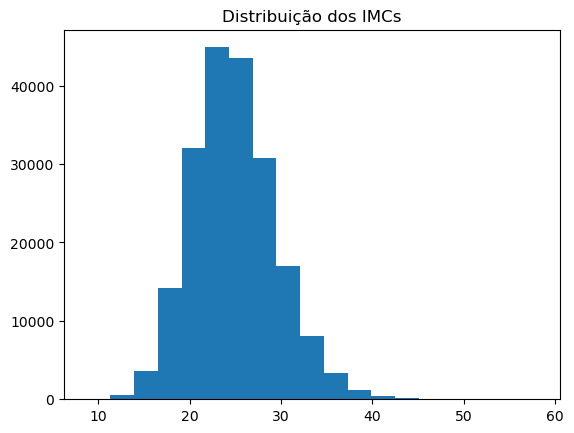

24.861001273206835
24.54806422057559
94473
105527
                         Freq. Absoluta  Freq. Relativa  Freq. Relativa %
riscos_imc                                                               
Peso normal                       94194        0.470970           47.0970
Acima do peso                     65942        0.329710           32.9710
Obesidade I                       21287        0.106435           10.6435
Abaixo do peso                     7837        0.039185            3.9185
Muito abaixo do peso               5785        0.028925            2.8925
Obesidade II                       3938        0.019690            1.9690
Obesidade III (mórbida)             657        0.003285            0.3285
Indefinido                          360        0.001800            0.1800


200000

In [19]:
plt.hist(df['imc'], bins='sturges')
plt.title('Distribuição dos IMCs')
plt.show()

print(df['imc'].mean())
print(df['imc'].median())
print((df['imc'] > df['imc'].mean()).sum())
print((df['imc'] < df['imc'].mean()).sum())

print(tabela_frequencia(df['riscos_imc']))
df['riscos_imc'].value_counts().sum()

### 3. Imagine que você trabalha como Cientista de Dados em um hospital e precisa desenvolver um sistema que ajude médicos a identificar pacientes em risco de problemas cardíacos com base no IMC. 
Se um paciente tem um IMC não exato (exemplo: 24.357896), qual conjunto numérico representa esse valor? O modelo precisa arredondar esse número? Justifique.

O conjunto numérico que representa esse valor é o conjunto dos números racionais, tendo como principal característica a possibilidade de representá-lo em formato de fração.

Para maior entendimento, legibilidade e apresentação, seria importante arredondar o IMC para pelo menos 2 casas decimais, ficando: 24.36. Para análises que requer maior precisão: manter o formato original.

### 4. O conceito de módulo (valor absoluto) pode ser útil na análise do IMC? Como?

Posso utilizar o módulo para calcular o desvio absoluto do IMC em relação à média. Dessa forma, fica mais legível para compreender em casos que a distância do dado em relação à média é um valor negativo.

Exemplo: digamos que para um determinado dado eu tenha uma média 40 e um dos meus pontos de dado seja 30,

ao realizarmos o cálculo da distância, seria: 30 - 40 = -10. Aplicando o desvio absoluto, o sinal ignoramos o sinal negativo: |30 - 40| = 10.